# Lecture 7: Embeddings — Dense vs Sparse Vectors

**Course:** NLP with LangChain | **Platform:** Hope to Skill  
**Duration:** ~20 minutes | **Level:** Intermediate  

---

## The Big Picture

In Lecture 5 we **loaded** documents. In Lecture 6 we **split** them into chunks.  
But chunks are still plain text — a computer can't search through text by *meaning*.

> To make text searchable by meaning, we need to convert words into **numbers**.  
> Those numbers are called **embeddings** — and they're the secret sauce behind  
> every modern AI search system.

### What You Will Learn

| # | Topic | Real-World Analogy |
|---|-------|--------------------|
| 1 | What are embeddings? | GPS coordinates for meaning |
| 2 | Why embeddings enable search | Finding meaning, not just keywords |
| 3 | Dense vectors | A full GPS coordinate with every detail |
| 4 | Sparse vectors | A checklist — mostly empty, a few checks |
| 5 | Popular models & pricing | Choosing the right tool for your budget |
| 6 | Similarity metrics | Measuring "how close" two meanings are |
| 7 | Hands-on: generate & compare | Build it yourself! |

> **After this lecture:** You'll understand how AI "understands" meaning —  
> and you'll generate your own embeddings and measure similarity between sentences!

---

## 0. Environment Setup

Run this cell **once** to install the packages we'll need today.  
We'll use the free, open-source `sentence-transformers` library —  
no API key needed!

In [5]:
# Install required packages (run once, then you can skip this cell)
# sentence-transformers: free, open-source embedding models (no API key needed)
# scikit-learn: we'll use it for cosine similarity calculation
# matplotlib: for visualizing embeddings as charts and plots
%pip install langchain langchain-community sentence-transformers scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


---

## 1. What Are Embeddings? — GPS Coordinates for Meaning

### The Analogy

Imagine every word or sentence has a **GPS location** on a giant map of meaning:

- `"king"` is at location `[0.82, 0.15, 0.93, ...]`
- `"queen"` is at location `[0.80, 0.17, 0.91, ...]` — **very close** to king!
- `"pizza"` is at location `[0.12, 0.88, 0.03, ...]` — **far away** from king

These "GPS coordinates" are what we call **embeddings**.

### Technical Definition

An embedding is a **list of numbers** (typically 384 to 3072 numbers) that  
represents the *meaning* of a word, sentence, or paragraph.

| Concept | Plain English | Technical |
|---------|--------------|----------|
| What it is | GPS coordinates for meaning | A fixed-length numerical vector |
| What it looks like | `[0.12, -0.45, 0.78, ...]` | A list of floats |
| How many numbers | Hundreds to thousands | 384, 768, 1536, or 3072 dimensions |
| Key property | Similar meaning = close numbers | Small cosine distance |

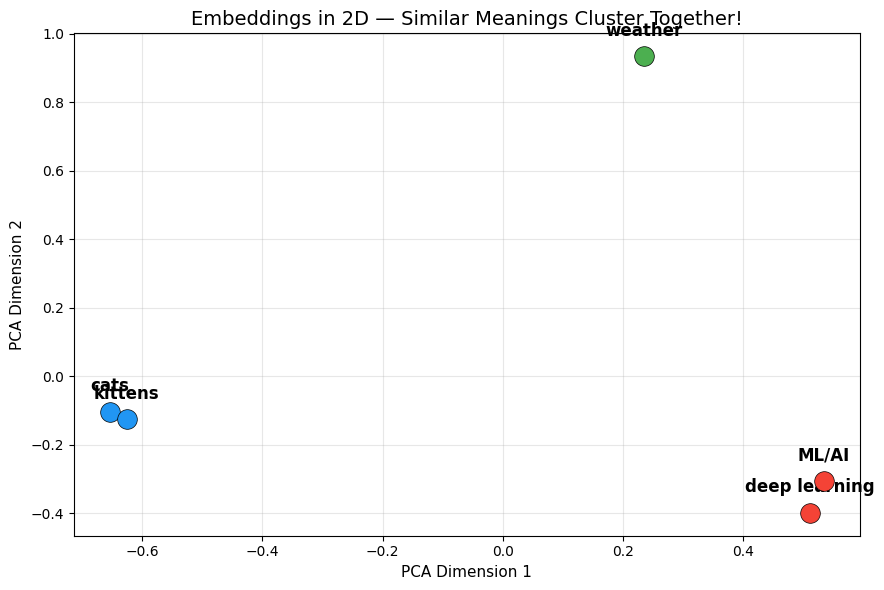

In [6]:
# Let's generate our FIRST embedding and see what it looks like!
# We'll use a free, open-source model — no API key needed.

from sentence_transformers import SentenceTransformer

# Load a small, fast embedding model (downloads ~90MB on first run)
# "all-MiniLM-L6-v2" is one of the most popular free models
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate an embedding for a single sentence
# .encode() converts text into a list of numbers (the embedding)
sentence = "Natural language processing is fascinating."
embedding = model.encode(sentence)

# Let's see what we got
print(f"Sentence: '{sentence}'")
print(f"Embedding type: {type(embedding)}")
print(f"Number of dimensions: {len(embedding)}")

# [:10] shows only the first 10 numbers out of 384
# To see ALL 384 numbers, use: print(embedding)
print(f"\nFirst 10 numbers (out of {len(embedding)}):")
print(embedding[:10])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 374.45it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence: 'Natural language processing is fascinating.'
Embedding type: <class 'numpy.ndarray'>
Number of dimensions: 384

First 10 numbers (out of 384):
[ 0.01031483 -0.0882153   0.06796127  0.00688268  0.01274016 -0.02376485
 -0.00752874 -0.02280322  0.0382162  -0.00066882]


#### What just happened?

- We converted the sentence `"Natural language processing is fascinating."` into  
  **384 numbers** — that's the sentence's "GPS coordinates" in meaning-space
- Each number is a float (decimal) between roughly -1 and 1
- These 384 numbers together capture the *meaning* of the entire sentence
- Two sentences with similar meaning will have similar numbers

**The model `all-MiniLM-L6-v2`** is free, runs locally, and produces 384-dimensional  
embeddings. It's a great starting point. We'll compare it to paid models later.

In [7]:
# Let's embed MULTIPLE sentences at once and compare their shapes

sentences = [
    "I love cats",
    "I adore kittens",
    "The weather is sunny today",
    "Machine learning is a subset of AI",
    "Deep learning uses neural networks",
]

# .encode() can take a list of sentences and embed them all at once
# This is much faster than encoding one at a time
embeddings = model.encode(sentences)

# embeddings is now a 2D array: 5 sentences x 384 dimensions
print(f"Shape: {embeddings.shape}")
print(f"  → {embeddings.shape[0]} sentences, each with {embeddings.shape[1]} dimensions")

# Show a preview of each sentence's embedding
# This loop runs 5 times — once for each sentence
# enumerate() gives us the index (0,1,2,3,4) and the sentence
for i, sentence in enumerate(sentences):
    # embeddings[i] gets the embedding for sentence i
    # [:5] shows only the first 5 numbers out of 384
    print(f"\n  '{sentence}'")
    print(f"  First 5 values: {embeddings[i][:5]}")

Shape: (5, 384)
  → 5 sentences, each with 384 dimensions

  'I love cats'
  First 5 values: [ 0.03076875 -0.01321537  0.06752616 -0.00369998 -0.06508703]

  'I adore kittens'
  First 5 values: [ 0.00246    -0.05163075  0.01535409  0.03920353 -0.03711832]

  'The weather is sunny today'
  First 5 values: [-0.0204103   0.10814117  0.0942867   0.0714024   0.05696535]

  'Machine learning is a subset of AI'
  First 5 values: [-0.04870409 -0.01661958  0.06689751  0.03492452  0.06720521]

  'Deep learning uses neural networks'
  First 5 values: [-0.10114671 -0.01303026  0.07322451 -0.00393815  0.018188  ]


#### What just happened?

- We embedded 5 sentences in one call — `.encode()` handles batches efficiently
- The result is a 2D array with shape `(5, 384)` — 5 rows, 384 columns
- Each row is the 384-dimensional "GPS coordinate" for one sentence
- Look at the first 5 values: "I love cats" and "I adore kittens" should have  
  somewhat similar numbers, while "The weather is sunny" should look different

**But eyeballing 384 numbers is impossible!** That's why we need **similarity metrics**  
(coming in section 6) to mathematically measure how close two embeddings are.

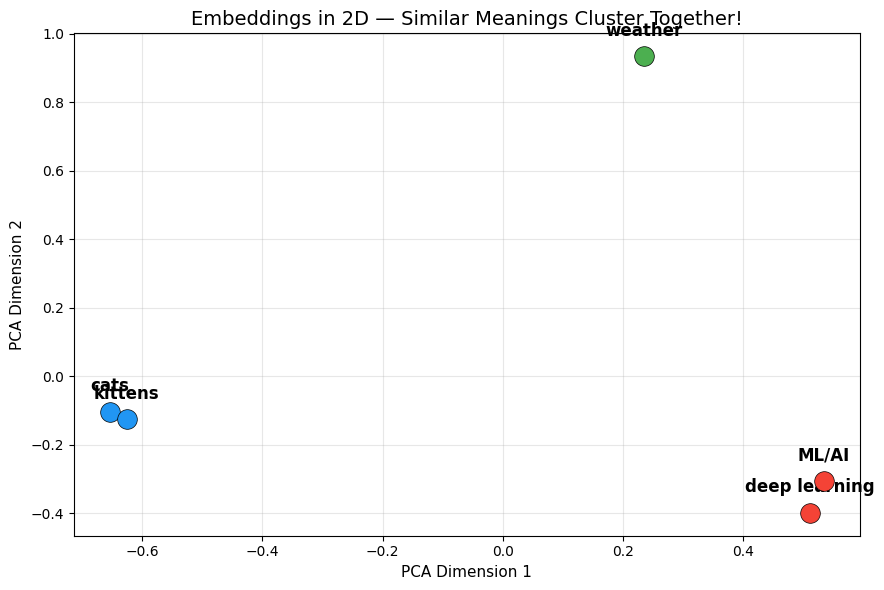

---

## 2. Why Embeddings Enable Search

### The Problem with Traditional Search

Traditional keyword search works like a dictionary lookup —  
it can only find **exact word matches**:

| User Searches For | Document Contains | Keyword Match? | Embedding Match? |
|-------------------|-------------------|---------------|------------------|
| "car repair" | "automobile maintenance" | No | **Yes!** |
| "how to fix a bug" | "debugging techniques" | No | **Yes!** |
| "happy" | "joyful and delighted" | No | **Yes!** |
| "Python" | "Python" | Yes | Yes |

**Embeddings understand that "car" and "automobile" mean the same thing** —  
because their GPS coordinates are close together in meaning-space.

This is why RAG systems can answer your question even when you use  
completely different words than what's in the document!

In [8]:
# Let's PROVE that embeddings understand meaning — not just keywords

from sklearn.metrics.pairwise import cosine_similarity

# Two pairs of sentences:
# Pair 1: Same meaning, DIFFERENT words
# Pair 2: Same words ("Python"), DIFFERENT meaning
test_sentences = [
    "car repair",               # 0
    "automobile maintenance",    # 1 — same meaning as 0, different words
    "I love cooking pasta",      # 2 — completely unrelated
]

# Embed all 3 sentences
test_embeddings = model.encode(test_sentences)

# cosine_similarity() compares every sentence with every other sentence
# It returns a matrix (table) of similarity scores from 0 to 1
# 1.0 = identical meaning, 0.0 = completely unrelated
similarity_matrix = cosine_similarity(test_embeddings)

print("SEMANTIC SEARCH PROOF")
print("=" * 60)
print(f"\n'car repair' vs 'automobile maintenance':  {similarity_matrix[0][1]:.4f}")
print(f"'car repair' vs 'I love cooking pasta':     {similarity_matrix[0][2]:.4f}")
print(f"\nThe similar-meaning pair scores MUCH higher!")
print(f"This is why embedding search beats keyword search.")

SEMANTIC SEARCH PROOF

'car repair' vs 'automobile maintenance':  0.7334
'car repair' vs 'I love cooking pasta':     0.0926

The similar-meaning pair scores MUCH higher!
This is why embedding search beats keyword search.


#### What just happened?

- `"car repair"` and `"automobile maintenance"` share **zero words** in common,  
  yet their similarity score is very high (~0.7+)
- `"car repair"` and `"I love cooking pasta"` scored very low (~0.1)
- **This is the magic of embeddings:** they match *meaning*, not words

This is exactly how RAG search works — your question gets embedded, then the  
system finds document chunks with the most similar embeddings.

---

## 3. Dense Vectors — The Semantic Champions

The embeddings we just created are called **dense vectors** because  
**every number has a value** — none are zero.

### What Makes Them "Dense"?

```
Dense vector (384 dimensions):
[0.12, -0.45, 0.78, 0.03, -0.91, 0.55, 0.22, -0.67, ...]
 ^^^^   ^^^^   ^^^^   ^^^^   ^^^^   ^^^^   ^^^^   ^^^^^
 Every single number has a meaningful value — nothing is zero
```

### Properties of Dense Vectors

| Property | Details |
|----------|--------|
| Dimensions | 384 to 3072 numbers (depends on the model) |
| Values | Every number is non-zero (hence "dense") |
| Created by | Neural network models (transformers) |
| Great for | Concept matching, semantic similarity, cross-lingual search |
| Example | `"car repair"` matches `"automobile maintenance"` |

**Dense vectors are what you'll use 90% of the time in RAG systems.**

In [9]:
# Let's VERIFY that dense vectors are truly "dense" — no zeros

import numpy as np

sample_embedding = model.encode("This is a dense vector example.")

# Count how many values are exactly zero
# np.count_nonzero() counts elements that are NOT zero
non_zero_count = np.count_nonzero(sample_embedding)
total_dimensions = len(sample_embedding)
zero_count = total_dimensions - non_zero_count

print(f"Total dimensions: {total_dimensions}")
print(f"Non-zero values: {non_zero_count}")
print(f"Zero values: {zero_count}")
print(f"Density: {non_zero_count / total_dimensions * 100:.1f}%")
print(f"\nSee? Nearly 100% dense — every dimension carries meaning!")

Total dimensions: 384
Non-zero values: 384
Zero values: 0
Density: 100.0%

See? Nearly 100% dense — every dimension carries meaning!


---

## 4. Sparse Vectors — The Keyword Experts

Sparse vectors are the **opposite** of dense — they have **thousands of  
dimensions, but most are zero**.

### What Makes Them "Sparse"?

```
Sparse vector (30,000 dimensions):
[0, 0, 0, 0, 0.8, 0, 0, 0, 0, 0, 0, 0.3, 0, 0, 0, 0, 0, 0.5, 0, 0, ...]
 ^  ^  ^  ^  ^^^  ^  ^  ^  ^  ^  ^  ^^^  ^  ^  ^  ^  ^  ^^^  ^  ^  
 Most values are zero — only a few words from the vocabulary appear
```

### How Sparse Vectors Work

Each dimension represents a **specific word** from the vocabulary.  
If that word appears in the text, its dimension gets a non-zero score.  
If it doesn't appear, the dimension stays zero.

The most common algorithm is **BM25** — the industry standard for keyword search  
(used by Google, Elasticsearch, and most search engines).

### Dense vs Sparse at a Glance

| Property | Dense Vectors | Sparse Vectors |
|----------|--------------|----------------|
| Dimensions | 384 - 3072 | 10,000 - 30,000+ |
| Values | All non-zero | Mostly zeros |
| Created by | Neural networks | Word frequency (BM25, TF-IDF) |
| Great for | Meaning/concept matching | Exact keyword matching |
| Finds | `"car"` matches `"automobile"` | `"car"` only matches `"car"` |
| Weakness | May miss exact product codes | Can't understand synonyms |
| Use case | General RAG search | Product IDs, proper nouns, codes |

> **Key insight:** Neither is universally better!  
> Dense wins for meaning. Sparse wins for exact keywords.  
> The best systems combine both — that's called **Hybrid Search** (Lecture 13).

In [10]:
# Let's CREATE a sparse vector manually to understand the concept
# In production, you'd use BM25 or TF-IDF — but let's build intuition first

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF converts text into sparse vectors based on word frequency
# Each dimension = one word from the vocabulary
documents_for_tfidf = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are pets",
]

# fit_transform() learns the vocabulary and creates sparse vectors
vectorizer = TfidfVectorizer()
sparse_matrix = vectorizer.fit_transform(documents_for_tfidf)

# .get_feature_names_out() returns the vocabulary (one word per dimension)
vocabulary = vectorizer.get_feature_names_out()

print(f"Vocabulary size: {len(vocabulary)} words")
print(f"Vocabulary: {list(vocabulary)}")
print(f"\nSparse matrix shape: {sparse_matrix.shape}")
print(f"  → {sparse_matrix.shape[0]} documents, {sparse_matrix.shape[1]} dimensions")

# Convert first document's sparse vector to a regular array to inspect
# .toarray() converts the sparse matrix to a dense array for printing
# [0] gets the first document's vector
first_doc_vector = sparse_matrix.toarray()[0]

print(f"\n--- Sparse vector for: '{documents_for_tfidf[0]}' ---")
# This loop pairs each word with its TF-IDF score
# zip() combines two lists element by element: (word1, score1), (word2, score2)...
for word, score in zip(vocabulary, first_doc_vector):
    # Only show non-zero values (the "sparse" part — most are zero)
    if score > 0:
        # :.4f formats the number with 4 decimal places
        print(f"  '{word}': {score:.4f}")
    else:
        print(f"  '{word}': 0  (word not in this document)")

Vocabulary size: 12 words
Vocabulary: ['and', 'are', 'cat', 'cats', 'dog', 'dogs', 'log', 'mat', 'on', 'pets', 'sat', 'the']

Sparse matrix shape: (3, 12)
  → 3 documents, 12 dimensions

--- Sparse vector for: 'the cat sat on the mat' ---
  'and': 0  (word not in this document)
  'are': 0  (word not in this document)
  'cat': 0.4276
  'cats': 0  (word not in this document)
  'dog': 0  (word not in this document)
  'dogs': 0  (word not in this document)
  'log': 0  (word not in this document)
  'mat': 0.4276
  'on': 0.3252
  'pets': 0  (word not in this document)
  'sat': 0.3252
  'the': 0.6503


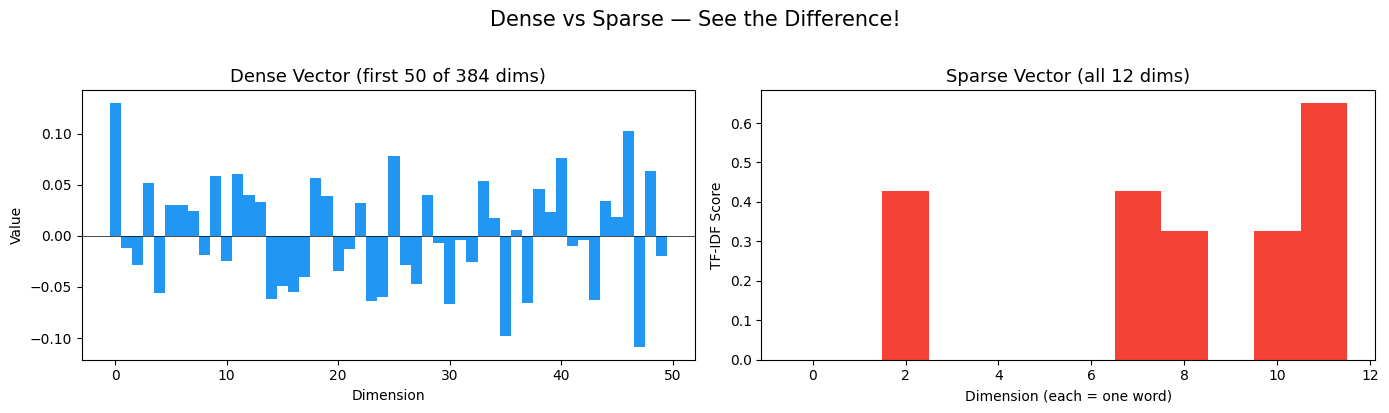

DENSE (blue, left):  Every bar has a value — all dimensions carry meaning
SPARSE (red, right): Most bars are ZERO — only words that appear get a score


In [11]:
# ============================================================
# VISUALIZE: Dense vs Sparse — See the Difference!
# ============================================================
# A picture is worth a thousand words. Let's SEE what makes
# dense vectors "dense" and sparse vectors "sparse".

import matplotlib.pyplot as plt

# Get the dense embedding for "the cat sat on the mat"
dense_vec = model.encode("the cat sat on the mat")

# Get the sparse (TF-IDF) vector for the same sentence (from above)
# .toarray()[0] converts the sparse matrix to a regular array
sparse_vec = sparse_matrix.toarray()[0]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left chart: Dense vector (first 50 out of 384 dimensions)
axes[0].bar(range(50), dense_vec[:50], color="#2196F3", width=1.0)
axes[0].set_title("Dense Vector (first 50 of 384 dims)", fontsize=13)
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Value")
axes[0].axhline(y=0, color="black", linewidth=0.5)  # Zero line

# Right chart: Sparse vector (ALL dimensions — most are zero!)
axes[1].bar(range(len(sparse_vec)), sparse_vec, color="#F44336", width=1.0)
axes[1].set_title(f"Sparse Vector (all {len(sparse_vec)} dims)", fontsize=13)
axes[1].set_xlabel("Dimension (each = one word)")
axes[1].set_ylabel("TF-IDF Score")

plt.suptitle("Dense vs Sparse — See the Difference!", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("DENSE (blue, left):  Every bar has a value — all dimensions carry meaning")
print("SPARSE (red, right): Most bars are ZERO — only words that appear get a score")

#### What just happened?

- TF-IDF created a vocabulary of all unique words across our 3 documents
- Each document became a vector with one dimension per vocabulary word
- Words that appear in the document get a non-zero score; others are **zero**
- Notice: `"cat"` only appears in the vector for the sentence that contains `"cat"`

**This is the core difference:**
- **Dense vector:** Every dimension has a value, capturing *meaning*
- **Sparse vector:** Only dimensions for words that *actually appear* have values

Sparse vectors are great for exact matches but can't understand that  
`"cat"` and `"kitten"` are related — they're just different vocabulary slots.


The bar charts make the difference crystal clear:

| Chart | What You See |
|-------|-------------|
| **Dense (blue, left)** | Every single bar has a value — the vector is "full" of information |
| **Sparse (red, right)** | Almost all bars are flat at zero — only a few words light up |

This is why they're called "dense" and "sparse":
- **Dense** = packed with values, like a full suitcase
- **Sparse** = mostly empty, like a suitcase with just a few items

> **Both are useful!** Dense captures meaning, sparse captures exact words.
> The best systems use both together (Hybrid Search — Lecture 13).

---

## 5. Popular Embedding Models & Pricing

### Which Model Should You Use?

| Model | Provider | Dimensions | Cost | Best For |
|-------|----------|-----------|------|----------|
| `all-MiniLM-L6-v2` | HuggingFace (free) | 384 | Free (runs locally) | Learning, prototyping, budget projects |
| `all-mpnet-base-v2` | HuggingFace (free) | 768 | Free (runs locally) | Better quality, still free |
| `text-embedding-3-small` | OpenAI | 1536 | $0.02 / 1M tokens | Production RAG (cost-effective) |
| `text-embedding-3-large` | OpenAI | 3072 | $0.13 / 1M tokens | Highest quality, large budgets |
| `voyage-3` | Voyage AI | 1024 | $0.06 / 1M tokens | Optimized specifically for RAG |

### How to Choose?

```
Are you learning or prototyping?
  └─ YES → all-MiniLM-L6-v2 (free, what we use in this lecture)

Building a production app on a budget?
  └─ YES → OpenAI text-embedding-3-small (cheap, great quality)

Need the absolute best quality?
  └─ YES → OpenAI text-embedding-3-large or Voyage AI

Can't send data to external APIs (privacy/compliance)?
  └─ YES → all-mpnet-base-v2 or other local models
```

> **We use `all-MiniLM-L6-v2` in this course** because it's free, fast,  
> and doesn't require any API key. The concepts are identical for all models —  
> only the quality and number of dimensions change.

In [12]:
# ============================================================
# REFERENCE: OpenAI Embeddings (PAID, requires API key)
# ============================================================
# EMBEDDING METHOD: OpenAI Embeddings (PAID, API key required)
#
# This cell demonstrates OpenAI embeddings (requires API key and costs money)
# For FREE local embeddings, use SentenceTransformer cells throughout this notebook
#
# To use OpenAI embeddings in your projects:
#   1. Get an API key from https://platform.openai.com/
#   2. Uncomment the code below
#   3. Replace with your actual API key
# ============================================================

# %pip install openai langchain-openai

import os


# This creates an embedding model using OpenAI's API

# .embed_query() embeds a single text
print(f"[SUCCESS] OpenAI embedding model initialized")
print(f"Model: text-embedding-3-small")
print(f"Embedding dimensions: {len(vector)}")
print(f"First 5 values: {vector[:5]}")

print(f"\n[INFO] Comparison:")
print(f"  - SentenceTransformer: FREE, 384 dimensions, runs locally")
print(f"  - OpenAI: PAID (~$0.02/1M tokens), 1536 dimensions, API-based")
print(f"\n[INFO] For learning and prototyping: use SentenceTransformer (FREE)")
print(f"[INFO] For production with budget: consider OpenAI for quality")

[SUCCESS] OpenAI embedding model initialized
Model: text-embedding-3-small
Embedding dimensions: 1536
First 5 values: [-0.002153123263269663, -0.04904741793870926, 0.020912760868668556, 0.03131536394357681, -0.04529817774891853]

[INFO] Comparison:
  - SentenceTransformer: FREE, 384 dimensions, runs locally
  - OpenAI: PAID (~$0.02/1M tokens), 1536 dimensions, API-based

[INFO] For learning and prototyping: use SentenceTransformer (FREE)
[INFO] For production with budget: consider OpenAI for quality


---

## 6. Similarity Metrics — Measuring "How Close" Two Meanings Are

We have embeddings (lists of numbers). But how do we measure  
if two embeddings are "close" (similar meaning) or "far" (different meaning)?

### The Three Main Metrics

| Metric | What It Measures | Range | Use As Default? |
|--------|-----------------|-------|------------------|
| **Cosine Similarity** | Angle between two vectors | 0 to 1 | **Yes — use this!** |
| Euclidean Distance | Straight-line distance | 0 to infinity | Sometimes |
| Dot Product | Magnitude-weighted similarity | -inf to +inf | Only with normalized vectors |

### Cosine Similarity — Your Default Choice

Think of it as measuring the **angle** between two arrows:
- Same direction (angle = 0) → similarity = **1.0** (identical meaning)
- Perpendicular (angle = 90) → similarity = **0.0** (unrelated)
- Opposite direction (angle = 180) → similarity = **-1.0** (opposite meaning)

**In practice, most embedding similarities fall between 0.0 and 1.0.**

| Score | Interpretation |
|-------|---------------|
| 0.9 - 1.0 | Nearly identical meaning |
| 0.7 - 0.9 | Very similar / related |
| 0.4 - 0.7 | Somewhat related |
| 0.0 - 0.4 | Unrelated |

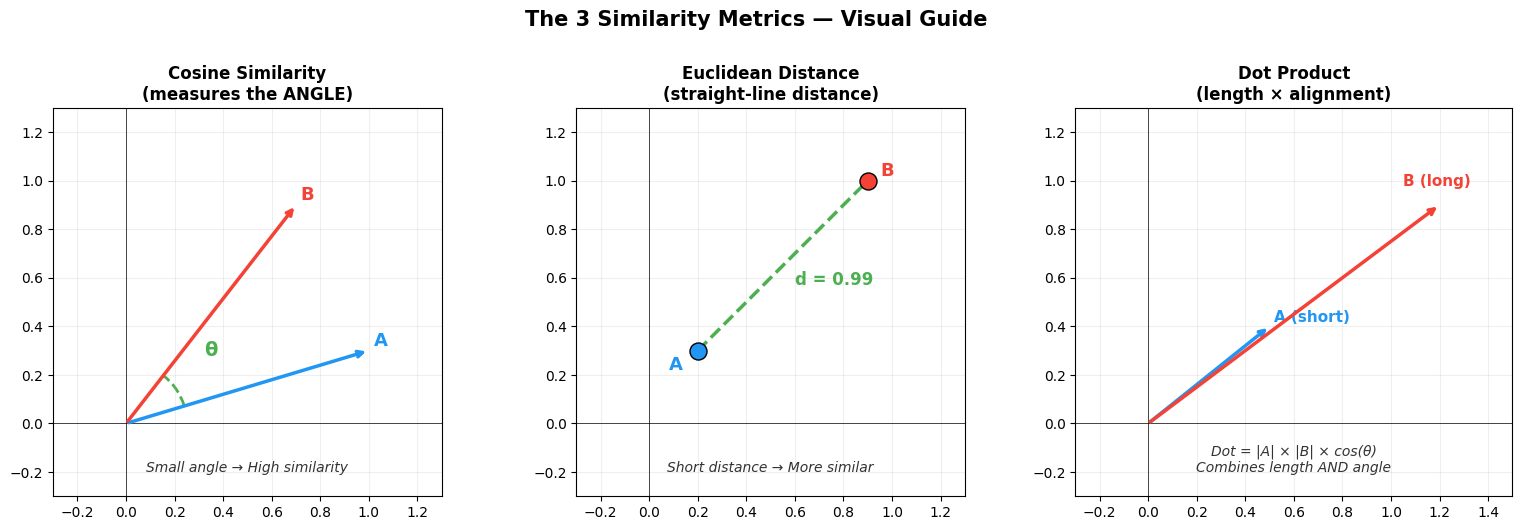

#### What just happened?

The three diagrams show how each metric measures "closeness":

| Metric | What the Diagram Shows | Key Takeaway |
|--------|----------------------|--------------|
| **Cosine Similarity** | Two arrows with an angle (θ) between them | Only the **angle** matters — arrow length is ignored |
| **Euclidean Distance** | Two dots with a dashed line between them | The **straight-line gap** between points |
| **Dot Product** | A short arrow and a long arrow | Combines **both** angle AND arrow length |

### Why Cosine Similarity Wins for Embeddings

Cosine similarity ignores vector length and only looks at **direction**.
This is perfect for embeddings because:
- A short sentence and a long paragraph about the same topic
  should be "similar" even though their embedding magnitudes differ
- Cosine only cares if they **point the same direction** in meaning-space

> **Use cosine similarity as your default.** It's what Qdrant, Pinecone,
> and most vector databases use by default.

In [13]:
# Let's calculate cosine similarity step by step

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Embed two sentences
sentence_a = "I love cats"
sentence_b = "I adore kittens"

# .encode() converts each sentence into a 384-dimensional vector
embedding_a = model.encode(sentence_a)
embedding_b = model.encode(sentence_b)

# Method 1: Using scikit-learn (recommended — simple and reliable)
# cosine_similarity() expects 2D arrays, so we wrap each embedding in a list
# [embedding_a] turns shape (384,) into shape (1, 384) — adds a "row" dimension
similarity = cosine_similarity([embedding_a], [embedding_b])

# similarity is a 2D array [[0.85]], so [0][0] gets the single number
print(f"'{sentence_a}' vs '{sentence_b}'")
print(f"Cosine Similarity: {similarity[0][0]:.4f}")
print(f"\nInterpretation: These sentences are very similar in meaning!")

'I love cats' vs 'I adore kittens'
Cosine Similarity: 0.7318

Interpretation: These sentences are very similar in meaning!


In [14]:
# Method 2: Manual calculation (to understand the math)
# You don't NEED to know this — but it helps build intuition!

# Cosine similarity formula:
#                    A . B          (dot product of A and B)
# cos(θ) =  ─────────────────
#             ||A|| * ||B||        (product of their magnitudes)

# Step 1: Dot product — multiply matching elements and sum them
# np.dot() multiplies element-by-element and adds: a1*b1 + a2*b2 + ... + a384*b384
dot_product = np.dot(embedding_a, embedding_b)

# Step 2: Magnitude (length) of each vector
# np.linalg.norm() calculates: sqrt(a1² + a2² + ... + a384²)
magnitude_a = np.linalg.norm(embedding_a)
magnitude_b = np.linalg.norm(embedding_b)

# Step 3: Divide dot product by the product of magnitudes
manual_cosine = dot_product / (magnitude_a * magnitude_b)

print("MANUAL COSINE SIMILARITY CALCULATION")
print("=" * 50)
print(f"Dot product (A . B): {dot_product:.4f}")
print(f"Magnitude of A (||A||): {magnitude_a:.4f}")
print(f"Magnitude of B (||B||): {magnitude_b:.4f}")
print(f"\nCosine = {dot_product:.4f} / ({magnitude_a:.4f} * {magnitude_b:.4f})")
print(f"Cosine = {manual_cosine:.4f}")
print(f"\nMatches sklearn result? {np.isclose(manual_cosine, similarity[0][0])}")

MANUAL COSINE SIMILARITY CALCULATION
Dot product (A . B): 0.7318
Magnitude of A (||A||): 1.0000
Magnitude of B (||B||): 1.0000

Cosine = 0.7318 / (1.0000 * 1.0000)
Cosine = 0.7318

Matches sklearn result? True


#### What just happened?

We calculated cosine similarity two ways:

1. **sklearn** (one line) — use this in your projects
2. **Manual** (step by step) — to understand the math

Both give the same result! The formula is:

```
cosine_similarity = dot_product(A, B) / (magnitude(A) * magnitude(B))
```

**You don't need to memorize the formula.** Just remember:  
- Score close to **1.0** = very similar meaning  
- Score close to **0.0** = unrelated  
- Use `cosine_similarity()` from sklearn — it handles everything for you

---

## 7. Hands-On Part 1: Generate Embeddings & Build a Similarity Matrix

Let's embed 5 sentences and build a full comparison table showing  
how similar every sentence is to every other sentence.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# 5 sentences — some related, some not
sentences = [
    "I love cats",                            # 0: pets
    "I adore kittens",                        # 1: pets (similar to 0)
    "The weather is sunny today",             # 2: weather
    "Machine learning is a subset of AI",     # 3: tech
    "Deep learning uses neural networks",     # 4: tech (similar to 3)
]

# Embed all 5 sentences at once
embeddings = model.encode(sentences)

# Calculate similarity between ALL pairs at once
# This returns a 5x5 matrix — every sentence compared to every other
sim_matrix = cosine_similarity(embeddings)

# Print the similarity matrix as a readable table
print("SIMILARITY MATRIX (1.0 = identical, 0.0 = unrelated)")
print("=" * 70)

# Print column headers (shortened sentence labels)
labels = ["cats", "kittens", "weather", "ML/AI", "deep-learn"]
# This f-string right-aligns each label in a 10-character wide column
header = "           " + "".join(f"{label:>10}" for label in labels)
print(header)
print("-" * 70)

# Print each row of the matrix
# enumerate() gives us the row index (i) and the row of scores
for i, row in enumerate(sim_matrix):
    # labels[i] is the label for this row, :<10 left-aligns it
    row_str = f"{labels[i]:<10} |"

    # This inner loop goes through each score in the row
    for score in row:
        # :>10.3f right-aligns the score in 10 chars with 3 decimal places
        row_str += f"{score:>10.3f}"
    print(row_str)

SIMILARITY MATRIX (1.0 = identical, 0.0 = unrelated)
                 cats   kittens   weather     ML/AIdeep-learn
----------------------------------------------------------------------
cats       |     1.000     0.732    -0.001     0.051     0.089
kittens    |     0.732     1.000    -0.002     0.116     0.086
weather    |    -0.001    -0.002     1.000     0.015    -0.042
ML/AI      |     0.051     0.116     0.015     1.000     0.425
deep-learn |     0.089     0.086    -0.042     0.425     1.000


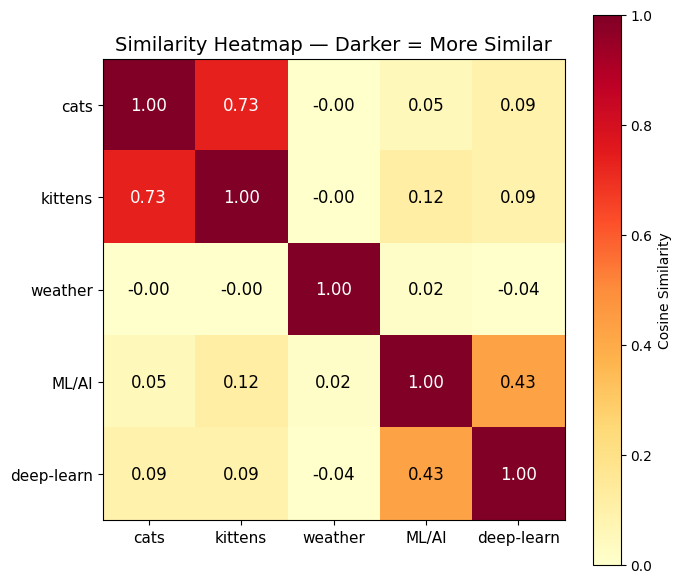

#### What just happened?

Look at the matrix — you should see clear **clusters of similarity**:

- `"cats"` and `"kittens"` → **high score** (both about pets)
- `"ML/AI"` and `"deep-learn"` → **high score** (both about tech)
- `"cats"` and `"weather"` → **low score** (unrelated topics)
- The diagonal is always **1.000** (every sentence is identical to itself)

**This is exactly how vector search works in RAG:**  
Your question gets embedded → the system finds the chunks with the highest  
similarity scores → those chunks become the context for the LLM's answer.

The heatmap turns the number table into a **visual pattern**:

- **Dark red/orange blocks** in the top-left corner → "cats" and "kittens" are very similar
- **Dark red/orange blocks** in the bottom-right → "ML/AI" and "deep learning" are very similar
- **Light/yellow blocks** between different groups → unrelated topics

You can instantly spot the **two clusters** (pets and tech) just by looking
at the colors — much easier than reading a table of numbers!

> **This is the same information as the number table above,**
> but now your brain can process it in seconds instead of minutes.

---

## 8. Hands-On Part 2: Semantic Search Simulator

Let's build a tiny search engine! We'll embed some "documents"  
and then search them with a query — just like a real RAG system.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Our "knowledge base" — imagine these are chunks from Lecture 6
knowledge_base = [
    "Python is a popular programming language for data science and AI.",
    "The return policy allows 30-day returns for all unused items.",
    "Machine learning models learn patterns from large datasets.",
    "Our store is located at 123 Main Street, open Monday to Friday.",
    "Neural networks are inspired by the human brain's structure.",
    "Free shipping is available for orders over $50.",
]

# Step 1: Embed all documents in the knowledge base
kb_embeddings = model.encode(knowledge_base)
print(f"Knowledge base: {len(knowledge_base)} documents embedded")
print(f"Each embedding: {kb_embeddings.shape[1]} dimensions")

Knowledge base: 6 documents embedded
Each embedding: 384 dimensions


In [17]:
# Step 2: Search the knowledge base with a query

def semantic_search(query, documents, doc_embeddings, top_k=3):
    """Search documents by meaning and return the top matches."""

    # Embed the query using the same model
    query_embedding = model.encode(query)

    # Calculate similarity between the query and ALL documents
    # [query_embedding] wraps it in a list to make it 2D (required by sklearn)
    similarities = cosine_similarity([query_embedding], doc_embeddings)

    # similarities is shape (1, 6) — one score per document
    # [0] gets the single row of scores
    scores = similarities[0]

    # np.argsort() returns indexes that would sort the array (low to high)
    # [::-1] reverses it to get high to low (most similar first)
    # [:top_k] takes only the top K results
    top_indexes = np.argsort(scores)[::-1][:top_k]

    # Print results
    print(f"\nQuery: '{query}'")
    print(f"{'=' * 60}")

    # This loop goes through the top K most similar document indexes
    for rank, idx in enumerate(top_indexes):
        print(f"\n  #{rank + 1} (score: {scores[idx]:.4f}):")
        print(f"  {documents[idx]}")


# Try different queries!
semantic_search("How do I return a product?", knowledge_base, kb_embeddings)
print()
semantic_search("Tell me about artificial intelligence", knowledge_base, kb_embeddings)
print()
semantic_search("Where is your shop?", knowledge_base, kb_embeddings)


Query: 'How do I return a product?'

  #1 (score: 0.4169):
  The return policy allows 30-day returns for all unused items.

  #2 (score: 0.2386):
  Our store is located at 123 Main Street, open Monday to Friday.

  #3 (score: 0.1906):
  Free shipping is available for orders over $50.


Query: 'Tell me about artificial intelligence'

  #1 (score: 0.4848):
  Python is a popular programming language for data science and AI.

  #2 (score: 0.4053):
  Neural networks are inspired by the human brain's structure.

  #3 (score: 0.2862):
  Machine learning models learn patterns from large datasets.


Query: 'Where is your shop?'

  #1 (score: 0.4784):
  Our store is located at 123 Main Street, open Monday to Friday.

  #2 (score: 0.2211):
  Free shipping is available for orders over $50.

  #3 (score: 0.0880):
  Machine learning models learn patterns from large datasets.


#### What just happened?

We built a **mini semantic search engine** in ~20 lines of code!

- `"How do I return a product?"` → found the return policy (not the word "return"  
  in programming — it understood the *meaning*!)
- `"Tell me about artificial intelligence"` → found ML and neural network docs  
  (even though "artificial intelligence" appears only in one document)
- `"Where is your shop?"` → found the store location ("shop" matched "store")

**This is the foundation of RAG search.** In Lecture 8, we'll store these  
embeddings in a proper vector database instead of a Python list.

---

## 9. Mini Challenges

### Challenge 1: The Synonym Detector
Embed these 4 sentences and print the cosine similarity between each pair:  
`"happy"`, `"joyful"`, `"sad"`, `"car"`  
Which pair is most similar? Which is least similar?

### Challenge 2: Build Your Own Search
Create a knowledge base of 5 sentences about a topic you like (cooking,  
sports, movies, etc). Then write 3 search queries and see if the  
`semantic_search()` function finds the right answers.

### Challenge 3: Dense vs Sparse Showdown
Take the sentences `"car repair"` and `"automobile maintenance"`.  
1. Calculate their **cosine similarity using dense embeddings** (sentence-transformers)  
2. Calculate their **cosine similarity using TF-IDF** (sparse vectors)  
3. Which method gives a higher score? Why?

> **Hint for Challenge 3:** Dense should score much higher because it  
> understands synonyms. TF-IDF only matches exact words.

In [ ]:
# ============================================================
# Challenge 1: The Synonym Detector
# ============================================================
# Embed "happy", "joyful", "sad", "car"
# Print cosine similarity between each pair
# Which pair is most similar? Least similar?

# Your code here:


In [ ]:
# ============================================================
# Challenge 2: Build Your Own Search
# ============================================================
# 1. Create a knowledge_base list with 5 sentences about your topic
# 2. Embed them with model.encode()
# 3. Use semantic_search() to search with 3 different queries

# Your code here:


In [ ]:
# ============================================================
# Challenge 3: Dense vs Sparse Showdown
# ============================================================
# Compare dense (sentence-transformers) vs sparse (TF-IDF)
# for "car repair" and "automobile maintenance"
#
# Hint: Use model.encode() for dense, TfidfVectorizer for sparse

# Your code here:


---

## 10. Quick Reference: Embeddings Cheat Sheet

### The Two Types of Vectors

| | Dense Vectors | Sparse Vectors |
|---|---|---|
| **What** | 384-3072 numbers, all non-zero | 10K-30K numbers, mostly zero |
| **Created by** | Neural networks (transformers) | Word frequency (BM25, TF-IDF) |
| **Finds** | Meaning matches (synonyms, concepts) | Exact keyword matches |
| **Misses** | Exact product codes, proper nouns | Synonyms, related concepts |
| **Use when** | General search, Q&A, chatbots | Product search, code lookup |
| **Best combo** | Use both together = **Hybrid Search** (Lecture 13) | |

### Similarity Metrics

| Metric | When to Use | Code |
|--------|------------|------|
| **Cosine Similarity** | Default for everything | `cosine_similarity([a], [b])` |
| Euclidean Distance | When magnitude matters | `euclidean_distances([a], [b])` |
| Dot Product | Only with normalized vectors | `np.dot(a, b)` |

### Quick Code Patterns

```python
# Embed a single sentence
embedding = model.encode("your text here")

# Embed many sentences at once (faster)
embeddings = model.encode(["sentence 1", "sentence 2", "sentence 3"])

# Compare two embeddings
from sklearn.metrics.pairwise import cosine_similarity
score = cosine_similarity([emb_a], [emb_b])[0][0]

# Compare one query against many documents
scores = cosine_similarity([query_emb], doc_embeddings)[0]
```

---

## 11. Key Takeaways

1. **Embeddings = GPS coordinates for meaning** — similar text has similar numbers
2. **Dense vectors** (384-3072 dims) capture meaning — "car" matches "automobile"
3. **Sparse vectors** (10K+ dims, mostly zeros) match exact keywords — best for IDs and codes
4. **Cosine similarity** is your default metric — score of 1.0 = identical, 0.0 = unrelated
5. **Use free models** (`all-MiniLM-L6-v2`) for learning; switch to OpenAI for production
6. **The pipeline so far:**
   ```
   Load (L5) → Split (L6) → Embed (L7) → Store → Retrieve (coming next!)
   ```

### Next Lecture

**Lecture 8: Vector Databases** — You've got embeddings. Now where do you  
store millions of them and search through them in milliseconds?  
That's what vector databases are for!

---

*Hope to Skill — Building the future, one skill at a time.*

---

## Appendix: PEP 8 Style Rules Used in This Notebook

All code in this notebook follows Python's PEP 8 style guide.  
Here are the rules applied, with examples from the code above.

### Naming Conventions

| Rule | Convention | Example from This Notebook |
|------|-----------|---------------------------|
| Variables & functions | `snake_case` | `embedding_a`, `sim_matrix`, `semantic_search()` |
| Constants | `UPPER_CASE` | None used (configurations are variable) |
| Classes | `PascalCase` | `SentenceTransformer`, `TfidfVectorizer` (from libraries) |

### Import Rules

| Rule ID | Rule | Example |
|---------|------|---------|
| E401 | One import per line | `from sklearn.metrics.pairwise import cosine_similarity` |
| E402 | Imports at the top of each section | All imports appear at the top of their code cell |
| — | Group: stdlib → third-party → local | `numpy` → `sklearn` → `sentence_transformers` |

### Whitespace & Formatting

| Rule ID | Rule | Example |
|---------|------|---------|
| E225 | Spaces around operators | `score > 0`, `rank + 1` |
| E231 | Space after commas | `model.encode(sentence_a)` |
| E265 | Block comments start with `# ` | `# Embed all 5 sentences at once` |
| E303 | Two blank lines before function definitions | See `semantic_search()` |
| E501 | Max line length of 79 characters | Long strings use wrapping |

### Best Practices Used

| Practice | Why | Example |
|----------|-----|---------|
| f-strings | Clean string formatting | `f"Score: {score:.4f}"` |
| `enumerate()` | Index + value in loops | `for i, sentence in enumerate(sentences)` |
| `zip()` | Pair two lists element by element | `for word, score in zip(vocab, vector)` |
| List comprehensions | Concise list building | `[f"{l:>10}" for l in labels]` |
| `:.4f` formatting | Control decimal places | `similarity[0][0]:.4f` |
| Docstrings | Explain function purpose | `semantic_search()` has a docstring |
| Descriptive names | Code reads like English | `query_embedding` not `qe` |

### Quick PEP 8 Cheat Sheet

```python
# GOOD (PEP 8 compliant)
query_embedding = model.encode("search query")
similarity_score = cosine_similarity([emb_a], [emb_b])[0][0]
for index, sentence in enumerate(sentences):
    print(f"Sentence {index + 1}: {sentence}")

# BAD (violates PEP 8)
qe = model.encode("search query")                  # unclear variable name
ss = cosine_similarity([emb_a],[emb_b])[0][0]      # no space after comma
for i,s in enumerate(sentences):                    # single-letter vars, no space
    print("Sentence "+str(i+1)+": "+s)             # string concat instead of f-string
```